# Granular Sentiment Pipeline: Class-Weighted Transformers for Steam Reviews


In [ ]:
# If running locally, install dependencies first: pip install -r ../requirements.txt
# (kept here as a fallback for Colab/hosted notebook environments)
!pip install transformers datasets scikit-learn -q

import os
os.makedirs('images', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)


### Importing all the depandancies


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)


### Loading the dataset

In [ ]:
steam_reviews = load_dataset("SirSkandrani/steam_reviews_clean")
df = steam_reviews['train'].to_pandas()

print(df.shape)
print(df['label'].value_counts())
print(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/363 [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/217M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/260M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/286M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/236M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4476233 [00:00<?, ? examples/s]

(4476233, 3)
label
 1    3650100
-1     826133
Name: count, dtype: int64
                                                text  label  __index_level_0__
0                                     ruined my life      1                  0
1  this will be more of a my experience with this...      1                  1
2                       this game saved my virginity      1                  2
3  • do you like original games • do you like gam...      1                  3
4             easy to learn hard to master                1                  4


### Index Level 0 has just indexes the reviews for which we have no need so will be dropping them

In [ ]:
df = df.drop(columns=['__index_level_0__'])
print(df.shape)
print(df['label'].value_counts())
print(df.head())

(4476233, 2)
label
 1    3650100
-1     826133
Name: count, dtype: int64
                                                text  label
0                                     ruined my life      1
1  this will be more of a my experience with this...      1
2                       this game saved my virginity      1
3  • do you like original games • do you like gam...      1
4             easy to learn hard to master                1


# Cleaning dataset


In [ ]:

# Assuming your dataframe is named 'df' and your column is 'text'
max_length = df['text'].str.len().max()
min_length = df['text'].str.len().min()

print(f"Maximum string length: {max_length}")
print(f"Minimum string length: {min_length}")

Maximum string length: 8001
Minimum string length: 0


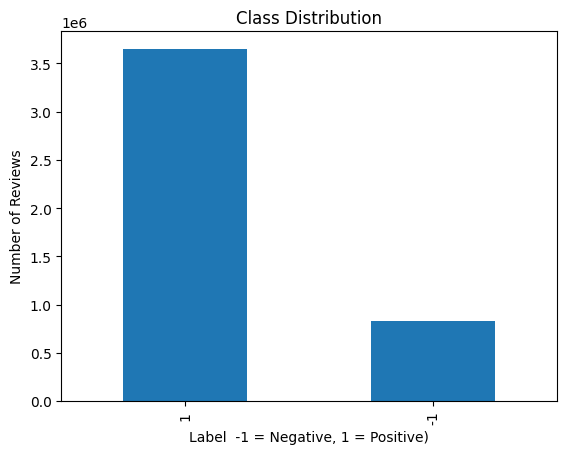

In [ ]:
df['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution')

plt.xlabel('Label  -1 = Negative, 1 = Positive)')
plt.ylabel('Number of Reviews')
plt.show()

In [ ]:
# Checking if there are null values in the dataset
has_nulls = df.isnull().values.any()

print(f" Has Null values - {has_nulls}")

 Has Null values - False


I might not have null values but I do have string value of 0 which would be empty data.

In [ ]:
# Droping null for good practice in case
df = df.dropna(subset=['text', 'label'])

# Droping 10 character word reviews to filter out noise
df = df[df['text'].str.strip().str.len() > 10]

# Limiting to 100 word review for model to run faster
df['text'] = df['text'].str[:512]
print(f"Clean dataset size: {len(df)}")


Clean dataset size: 4454846


The dataset size dropped from 4476233 to 4454846 which is just 0.4% of the dataset lost which is neglible so dataset was clean from the start

# Labelling Sentiments

### Checking the frequency of words in each pre defined labels which is -1 and 1

In [ ]:
# Will be taking a sample of both positive and negative reviews of 50,000 to get better reach of words
positive_df = df[df['label'] == 1].sample(50000, random_state=42)
negative_df = df[df['label'] == -1].sample(50000, random_state=42)

print(f"Positive reviews for analysis: {len(positive_df)}")
print(f"Negative reviews for analysis: {len(negative_df)}")

Positive reviews for analysis: 50000
Negative reviews for analysis: 50000


### Will be checking top 25 frequent words in Postive and Negetive reviews

In [ ]:
from collections import Counter

STOPWORDS = {
    # Articles, prepositions, conjunctions
    'the','and','for','this','that','with','from','into','onto','upon',
    'but','not','are','was','were','has','have','had','been','will',
    'would','could','should','may','might','shall','can','did','does',
    'its','it','is','in','of','to','on','at','as','an','or','be','by',
    'so','my','up','no','do','me','if','we','he','she','they','you',
    # Common filler
    'just','very','really','also','more','some','your','when','even',
    'than','what','there','time','only','about','much','most','then',
    'now','how','which','still','any','way','got','over','other','too',
    'after','first','well','back','get','out','all','one','because',
    'though','dont','cant','im','ive','its','wont','didnt','wasnt',
    # Game-specific noise
    'game','games','play','playing','played','player','buy','bought',
    'recommend','recommended','lot','like','good','great','bad','fun',
    'amazing','awesome','pretty','better','best','new','make','want',
    'had','got','would','could','though','their','them','these','those',
    'money','hours','worth','story','graphics','gameplay', 'people'
}

### Printing top 40 words in positive and negetive reviews

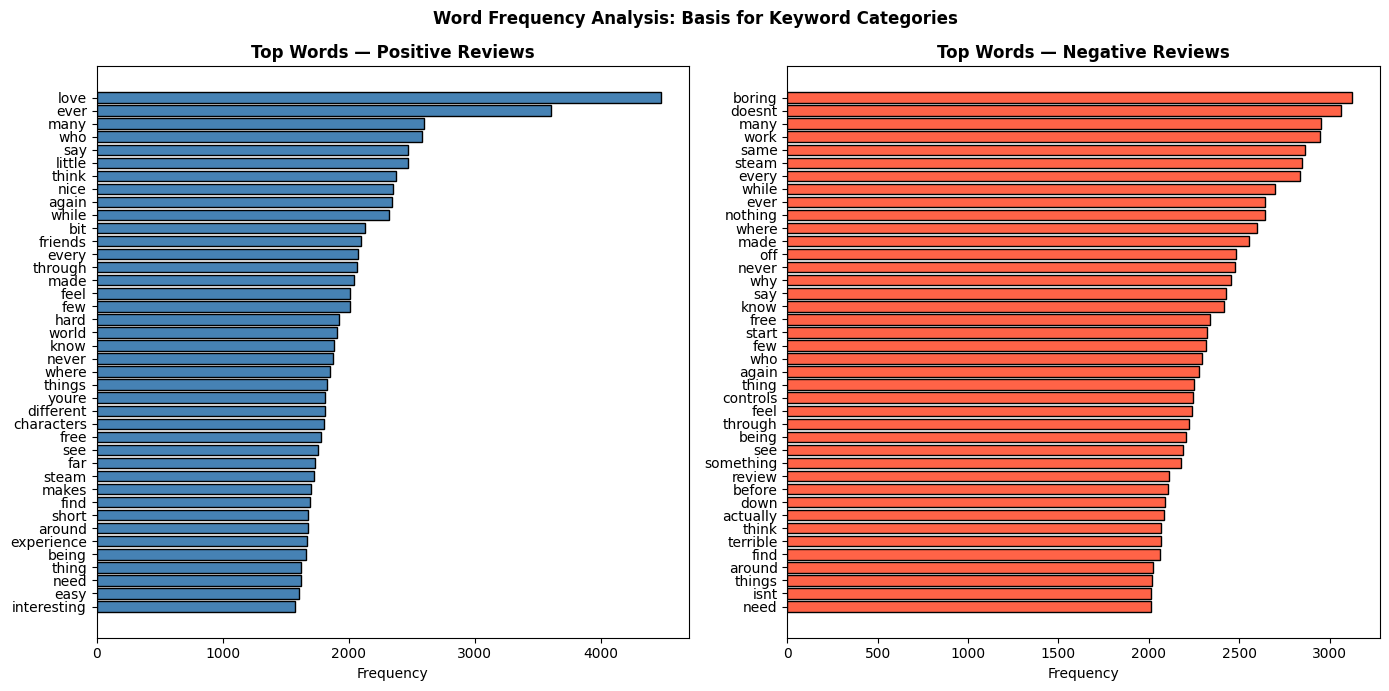

In [ ]:
import re
def top_words(texts, n=40):
    words = re.findall(r'\b[a-z]{3,}\b', ' '.join(texts).lower())
    return Counter(w for w in words if w not in STOPWORDS).most_common(n)

pos_freq = top_words(positive_df['text'])
neg_freq = top_words(negative_df['text'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
for ax, freq, title, color in [
    (ax1, pos_freq, 'Positive Reviews', 'steelblue'),
    (ax2, neg_freq, 'Negative Reviews', 'tomato')
]:
    words, counts = zip(*freq)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black')
    ax.set_title(f'Top Words — {title}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Word Frequency Analysis: Basis for Keyword Categories', fontweight='bold')
plt.tight_layout()
plt.savefig('images/word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

The graph above gives a good overview what words appear the mosts revealing on how we will be seperating the labelling system.

In [ ]:
# Postive keywords
gameplay_words = [
    'gameplay', 'mechanic', 'mechanics', 'combat', 'controls',
    'exploration', 'fun', 'addictive', 'satisfying', 'smooth',
    'responsive', 'fighting', 'shooting', 'movement', 'physics',
    'challenge', 'challenging', 'difficulty', 'boss', 'level design',
    'replayability', 'replay', 'hours', 'grind', 'progression'
]

narrative_words = [
    'story', 'narrative', 'plot', 'character', 'characters',
    'writing', 'dialogue', 'lore', 'worldbuilding', 'world building',
    'cutscene', 'ending', 'twist', 'immersive', 'immersion',
    'choices', 'decision', 'roleplay', 'rpg elements', 'voice acting'
]

aesthetics_words = [
    'graphics', 'visuals', 'art style', 'artstyle', 'beautiful',
    'stunning', 'gorgeous', 'music', 'soundtrack', 'sound design',
    'atmosphere', 'atmospheric', 'aesthetic', 'animation', 'animations',
    'lighting', 'art direction', 'pixel art', 'hand drawn', 'score'
]

# Negative keywords
technical_words = [
    'bug', 'bugs', 'buggy', 'glitch', 'glitches', 'crash', 'crashes',
    'crashing', 'freeze', 'freezes', 'lag', 'lagging', 'fps',
    'performance', 'stutter', 'stuttering', 'black screen', 'wont launch',
    "won't launch", 'doesnt work', "doesn't work", 'broken', 'unplayable',
    'error', 'errors', 'corrupt', 'save', 'patch', 'uninstall',
    'refund', 'never worked', 'still not fixed', 'optimization'
]

price_words = [
    'price', 'expensive', 'cheap', 'worth', 'value', 'money',
    'cost', 'dlc', 'microtransaction', 'microtransactions', 'pay to win',
    'pay2win', 'p2w', 'paywall', 'overpriced', 'rip off', 'ripoff',
    'not worth', 'waste of money', 'refund', 'sale', 'full price',
    'season pass', 'premium', 'subscription'
]

design_words = [
    'boring', 'repetitive', 'tedious', 'pacing', 'grindy',
    'too short', 'shallow', 'empty', 'lack of content', 'no content',
    'bad design', 'poor design', 'disappointing', 'disappointed',
    'frustrating', 'unfair', 'unbalanced', 'poorly designed',
    'padding', 'copy paste', 'generic', 'nothing new', 'lazy',
    'bad ai', 'stupid ai', 'bad story', 'terrible writing'
]


In [ ]:
categories = {
    'Positive_Gameplay':   (positive_df, gameplay_words),
    'Positive_Narrative':  (positive_df, narrative_words),
    'Positive_Aesthetics': (positive_df, aesthetics_words),
    'Technical_Issues':    (negative_df, technical_words),
    'Price_Sensitive':     (negative_df, price_words),
    'Negative_Design':     (negative_df, design_words),
}

coverages = []
for name, (source_df, keywords) in categories.items():
    hits = source_df['text'].str.lower().apply(lambda x: any(kw in x for kw in keywords))
    coverages.append(hits.mean() * 100)
    print(f"{name}: {hits.sum()} reviews ({hits.mean()*100:.1f}%)")

Positive_Gameplay: 19476 reviews (39.0%)
Positive_Narrative: 10321 reviews (20.6%)
Positive_Aesthetics: 7314 reviews (14.6%)
Technical_Issues: 13017 reviews (26.0%)
Price_Sensitive: 11589 reviews (23.2%)
Negative_Design: 6762 reviews (13.5%)


## Lets visualize the chart and output some samples to see if it is working

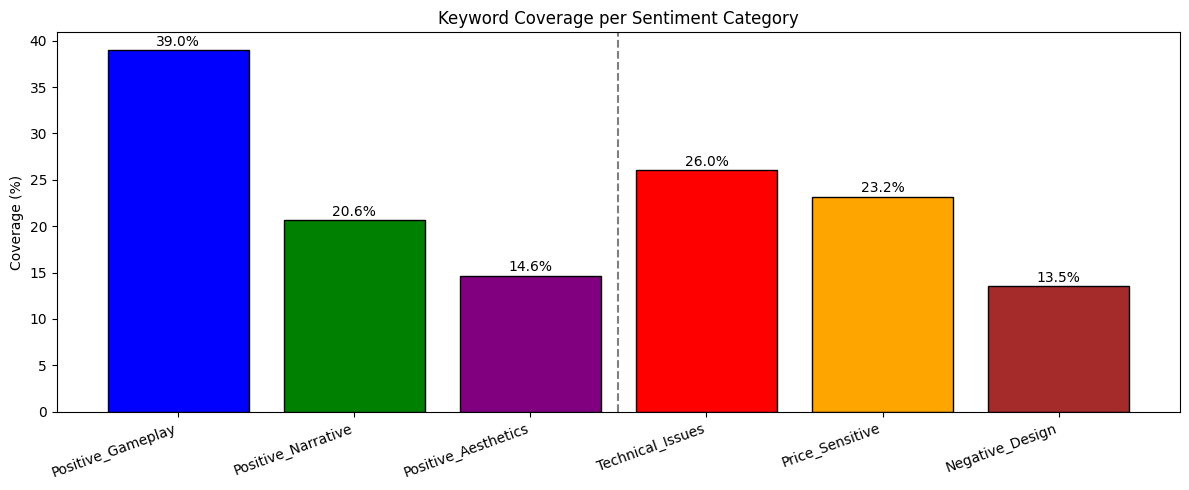


Positive_Gameplay
  - i loved doom it was exactly what i wanted i wanted to run around killing demons and punching them through the face i thoroughly enjoyed ripping body p

  - tight controls wonderfully colorful pixel graphics and interesting level design makes this platform gem both feel nostalgic and refreshing at the same


Positive_Narrative
  - i really wasnt sure what to expect from yet another tale based on the cinderella formula but this visual novel was really good the writing kept me int

  - if you like anime then you will probably like this not worth full price tho  pros  cool artstyle decent combat dual audio awesome for people who cant 


Positive_Aesthetics
  - payday 2 is like left 4 dead meets grand theft auto and the result is a beautifully fun game to play with friends  and i specifically say with friends

  - bright lights music explosions whats not to like


Technical_Issues
  - cant play movies without heavy stuttering due to crappy bink player developers dont 

In [ ]:
# coverage chart
colors = ['blue', 'green', 'purple', 'red', 'orange', 'brown']
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(categories.keys(), coverages, color=colors, edgecolor='black')

for bar, val in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center')

ax.axvline(x=2.5, color='black', linestyle='--', alpha=0.5)
ax.set_title('Keyword Coverage per Sentiment Category')
ax.set_ylabel('Coverage (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('images/coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# sample reviews per category
for name, (source_df, keywords) in categories.items():
    matched = source_df[source_df['text'].str.lower().apply(lambda x: any(kw in x for kw in keywords))]
    print(f"\n{name}")
    for ex in matched['text'].sample(2, random_state=42).values:
        print(f"  - {ex[:150]}\n")

In [ ]:
# Coverage chart
label_names = {
    0: 'Positive_Gameplay',
    1: 'Positive_Narrative',
    2: 'Positive_Aesthetics',
    3: 'Technical_Issues',
    4: 'Price_Sensitive',
    5: 'Negative_Design'
}

Seeing that our seperation labels is working quite well we will be now Applying the 6 Class Labels to Full dataset.

In [ ]:
def assign_label(row):
    text = row['text'].lower()
    if row['label'] == 1:
        scores = {
            0: sum(1 for kw in gameplay_words   if kw in text),
            1: sum(1 for kw in narrative_words  if kw in text),
            2: sum(1 for kw in aesthetics_words if kw in text),
        }
        best = max(scores, key=scores.get)
        return best if scores[best] > 0 else 0
    else:
        scores = {
            3: sum(1 for kw in technical_words if kw in text),
            4: sum(1 for kw in price_words     if kw in text),
            5: sum(1 for kw in design_words    if kw in text),
        }
        best = max(scores, key=scores.get)
        return best if scores[best] > 0 else 5

df['sentiment'] = df.apply(assign_label, axis=1)
df['sentiment_name'] = df['sentiment'].map(label_names)

print(df['sentiment_name'].value_counts())

sentiment_name
Positive_Gameplay      3030990
Negative_Design         478474
Positive_Narrative      411812
Technical_Issues        202175
Positive_Aesthetics     189589
Price_Sensitive         141806
Name: count, dtype: int64


In [ ]:
# Disable interactive widgets for clean notebook export
from transformers.utils import logging
logging.set_verbosity_info()

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Force plain text progress bars instead of widgets
from tqdm.auto import tqdm
import tqdm.auto
tqdm.auto.tqdm = tqdm.tqdm

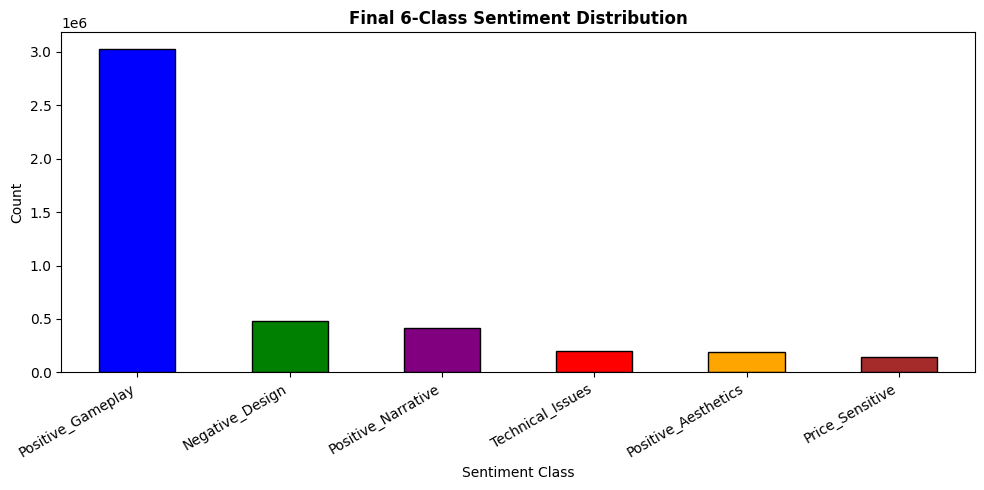

In [ ]:
df['sentiment_name'].value_counts().plot(
    kind='bar', figsize=(10,5), color=colors, edgecolor='black'
)
plt.title('Final 6-Class Sentiment Distribution', fontweight='bold')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('images/final_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The distribution reveals significant class imbalance. Positive_Gameplay dominates
at 68% as it acts as the default positive category for reviews lacking specific
narrative or aesthetic keywords. To address this we will undersample the dominant
class and apply class weights during training.

In [ ]:
MAX_PER_CLASS = 284771 # Took the mean of the rest of the values to come to this number

gameplay_idx = df[df['sentiment'] == 0].sample(MAX_PER_CLASS, random_state=42).index
df_balanced = df[(df['sentiment'] != 0) | (df.index.isin(gameplay_idx))]

print(df_balanced['sentiment_name'].value_counts())

sentiment_name
Negative_Design        478474
Positive_Narrative     411812
Positive_Gameplay      284771
Technical_Issues       202175
Positive_Aesthetics    189589
Price_Sensitive        141806
Name: count, dtype: int64


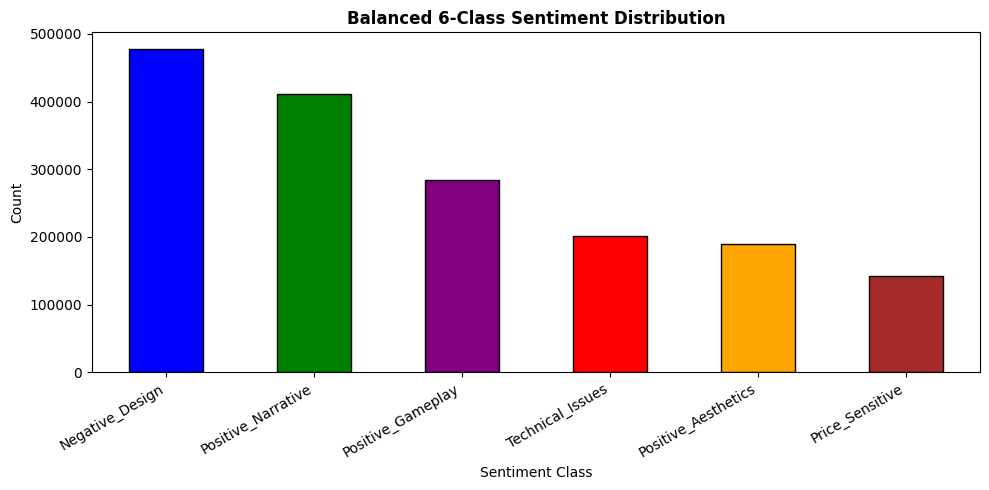

In [ ]:
df_balanced['sentiment_name'].value_counts().plot(
    kind='bar', figsize=(10,5), color=colors, edgecolor='black'
)
plt.title('Balanced 6-Class Sentiment Distribution', fontweight='bold')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('images/balanced_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

After undersampling Positive_Gameplay to 284,771 samples the distribution is
significantly more balanced. Class weights will further compensate for remaining
imbalance during training.

In [ ]:
classes = np.array([0,1,2,3,4,5])
weights = compute_class_weight('balanced', classes=classes, y=df_balanced['sentiment'])
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

df_subset, _ = train_test_split(df_balanced, train_size=20000, stratify=df_balanced['sentiment'], random_state=42)
train_df, temp_df = train_test_split(df_subset, test_size=0.3, stratify=df_subset['sentiment'], random_state=42)
val_df, test_df   = train_test_split(temp_df,   test_size=0.5, stratify=temp_df['sentiment'],   random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(train_df['sentiment_name'].value_counts())

df_subset.to_csv('data/df_subset.csv', index=False)

Class weights: {np.int64(0): np.float64(1.0000005852655878), np.int64(1): np.float64(0.6915076944495708), np.int64(2): np.float64(1.5020447740463143), np.int64(3): np.float64(1.4085379827707019), np.int64(4): np.float64(2.0081743132636607), np.int64(5): np.float64(0.5951653938702347)}
Train: 14000 | Val: 3000 | Test: 3000
sentiment_name
Negative_Design        3921
Positive_Narrative     3374
Positive_Gameplay      2333
Technical_Issues       1657
Positive_Aesthetics    1553
Price_Sensitive        1162
Name: count, dtype: int64


The class weights are now somewhat being balanced but there is still huge difference between the first 3

### So now we will be capping Dominant Classes to Reduce Imbalance
After observing the skewed distribution, we cap any class exceeding 150,000 samples
to bring all categories to a comparable scale before subsetting.

In [ ]:
MAX_PER_CLASS = 150000

def cap_class(dataframe, label, max_n):
    idx = dataframe[dataframe['sentiment'] == label].sample(max_n, random_state=42).index
    return dataframe[(dataframe['sentiment'] != label) | (dataframe.index.isin(idx))]

df_balanced = df.copy()
for label in range(6):
    if len(df_balanced[df_balanced['sentiment'] == label]) > MAX_PER_CLASS:
        df_balanced = cap_class(df_balanced, label, MAX_PER_CLASS)

print(df_balanced['sentiment_name'].value_counts())

sentiment_name
Positive_Gameplay      150000
Positive_Narrative     150000
Positive_Aesthetics    150000
Technical_Issues       150000
Negative_Design        150000
Price_Sensitive        141806
Name: count, dtype: int64


### Recomputing Class Weights and Splits on Balanced Dataset
With a balanced distribution we recompute class weights and recreate the
train/validation/test splits to ensure fair representation across all 6 sentiment categories.

In [ ]:
classes = np.array([0,1,2,3,4,5])
weights = compute_class_weight('balanced', classes=classes, y=df_balanced['sentiment'])
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

df_subset, _ = train_test_split(df_balanced, train_size=20000, stratify=df_balanced['sentiment'], random_state=42)
train_df, temp_df = train_test_split(df_subset, test_size=0.3, stratify=df_subset['sentiment'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df['sentiment'], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(train_df['sentiment_name'].value_counts())

df_subset.to_csv('data/df_subset.csv', index=False)
print("Saved to Drive")

Class weights: {np.int64(0): np.float64(0.9908955555555555), np.int64(1): np.float64(0.9908955555555555), np.int64(2): np.float64(0.9908955555555555), np.int64(3): np.float64(0.9908955555555555), np.int64(4): np.float64(1.0481526404618517), np.int64(5): np.float64(0.9908955555555555)}
Train: 14000 | Val: 3000 | Test: 3000
sentiment_name
Positive_Narrative     2355
Positive_Gameplay      2355
Positive_Aesthetics    2355
Negative_Design        2355
Technical_Issues       2354
Price_Sensitive        2226
Name: count, dtype: int64
Saved to Drive



The rebalanced training set shows near-perfect class distribution with approximately
2,350 samples per class. Price_Sensitive is marginally lower at 2,226 samples as it
is genuinely the rarest category in the dataset users who leave negative reviews
focused purely on pricing represent a smaller subset of Steam reviewers. The class
weights computed earlier will compensate for this minor remaining imbalance during
training.

## Now building HuggingFace Datasets

In [ ]:
NUM_LABELS = 6

def make_hf_dataset(dataframe):
    return Dataset.from_dict({
        'text':  dataframe['text'].tolist(),
        'label': dataframe['sentiment'].tolist()
    })

train_ds = make_hf_dataset(train_df)
val_ds   = make_hf_dataset(val_df)
test_ds  = make_hf_dataset(test_df)
print("Datasets ready")

Datasets ready


In [ ]:
import torch.nn as nn
from transformers import Trainer
import torch

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(
            [class_weights[i] for i in range(len(class_weights))],
            dtype=torch.float
        ).to('cuda' if torch.cuda.is_available() else 'cpu')

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(
            outputs.logits, labels
        )
        return (loss, outputs) if return_outputs else loss

## Models Training
#### Three transformer models are fine-tuned for comparison:
- DistilBERT: lightweight baseline
- BERTweet: domain-specific (pretrained on social media text)  
- RoBERTa: robustly optimised general-purpose model

## Model 1 Train: DistilBERT

In [ ]:
MODEL = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM_LABELS)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=TrainingArguments(
        output_dir="checkpoints/distilbert_results",
        num_train_epochs=4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        learning_rate=2e-5,
        logging_steps=50,
        warmup_steps=100,
        weight_decay=0.01,
    ),
    train_dataset=train_tok,
    eval_dataset=val_tok,
)

trainer.train()
trainer.save_model("checkpoints/distilbert_saved")
tokenizer.save_pretrained("checkpoints/distilbert_saved")
print("DistilBERT done and saved")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT done and saved


## Model 2 Train: BERTweet

In [ ]:
MODEL_2 = "vinai/bertweet-base"
tokenizer2 = AutoTokenizer.from_pretrained(MODEL_2)

tok_fn2 = lambda b: tokenizer2(b['text'], padding='max_length', truncation=True, max_length=128)
train_tok2 = train_ds.map(tok_fn2, batched=True)
val_tok2   = val_ds.map(tok_fn2, batched=True)
test_tok2  = test_ds.map(tok_fn2, batched=True)

model2 = AutoModelForSequenceClassification.from_pretrained(MODEL_2, num_labels=NUM_LABELS)

trainer2 = WeightedTrainer(
    class_weights=class_weights,
    model=model2,
    args=TrainingArguments(
        output_dir="checkpoints/bertweet_results",
        num_train_epochs=4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        learning_rate=2e-5,
        logging_steps=50,
        warmup_steps=100,
        weight_decay=0.01,
    ),
    train_dataset=train_tok2,
    eval_dataset=val_tok2,
)

trainer2.train()
trainer2.save_model("checkpoints/bertweet_saved")
tokenizer2.save_pretrained("checkpoints/bertweet_saved")
print("BERTweet done and saved")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERTweet done and saved


## Model 3 Train: RoBERTa

In [ ]:
MODEL_3 = "roberta-base"
tokenizer3 = AutoTokenizer.from_pretrained(MODEL_3)

tok_fn3 = lambda b: tokenizer3(b['text'], padding='max_length', truncation=True, max_length=128)
train_tok3 = train_ds.map(tok_fn3, batched=True)
val_tok3   = val_ds.map(tok_fn3, batched=True)
test_tok3  = test_ds.map(tok_fn3, batched=True)

model3 = AutoModelForSequenceClassification.from_pretrained(MODEL_3, num_labels=NUM_LABELS)

trainer3 = WeightedTrainer(
    class_weights=class_weights,
    model=model3,
    args=TrainingArguments(
        output_dir="checkpoints/roberta_results",
        num_train_epochs=4,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        learning_rate=2e-5,
        logging_steps=50,
        warmup_steps=100,
        weight_decay=0.01,
    ),
    train_dataset=train_tok3,
    eval_dataset=val_tok3,
)

trainer3.train()
trainer3.save_model("checkpoints/roberta_saved")
tokenizer3.save_pretrained("checkpoints/roberta_saved")
print("RoBERTa done and saved")

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Could not locate the best model at /content/drive/MyDrive/CI7525/roberta_results/checkpoint-3500/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa done and saved


### Epoch Selection
Training was conducted over 4 epochs across all models. Initial experiments
indicated overfitting beyond 4 epochs, with validation loss increasing while
training loss continued to decrease. 4 epochs was selected as the optimal
stopping point, balancing convergence and generalisation on the 20,000 sample
subset. Identical hyperparameters were applied across all three models to ensure
any performance differences reflect architecture rather than training conditions.

In [ ]:
def print_epoch_table(trainer, model_name):
    logs = trainer.state.log_history

    train = {round(l['epoch']): round(l['loss'], 4)
             for l in logs if 'loss' in l and 'eval_loss' not in l}

    rows = [{'Epoch': int(l['epoch']),
             'Train Loss': train.get(int(l['epoch']), train.get(int(l['epoch'])-1, float('nan'))),
             'Val Loss': round(l['eval_loss'], 4)}
            for l in logs if 'eval_loss' in l]

    print(f"\n=== {model_name} ===")
    print(pd.DataFrame(rows).to_string(index=False))

print_epoch_table(trainer,  "DistilBERT")
print_epoch_table(trainer2, "BERTweet")
print_epoch_table(trainer3, "RoBERTa")


=== DistilBERT ===
 Epoch  Train Loss  Val Loss
     1      0.4513    0.5584
     2      0.2748    0.4682
     3      0.1320    0.4905
     4      0.2373    0.5227

=== BERTweet ===
 Epoch  Train Loss  Val Loss
     1      0.4023    0.4896
     2      0.2142    0.4160
     3      0.1943    0.4569

=== RoBERTa ===
 Epoch  Train Loss  Val Loss
     1      0.4773    0.5277
     2      0.3606    0.5088
     3      0.1580    0.5634
     4      0.1838    0.6410


## Evaluation of 3 Models


  DistilBERT
                     precision    recall  f1-score   support

  Positive_Gameplay       0.79      0.70      0.75       505
 Positive_Narrative       0.84      0.91      0.87       504
Positive_Aesthetics       0.88      0.93      0.91       505
   Technical_Issues       0.87      0.89      0.88       505
    Price_Sensitive       0.90      0.88      0.89       477
    Negative_Design       0.80      0.77      0.78       504

           accuracy                           0.85      3000
          macro avg       0.85      0.85      0.85      3000
       weighted avg       0.85      0.85      0.85      3000



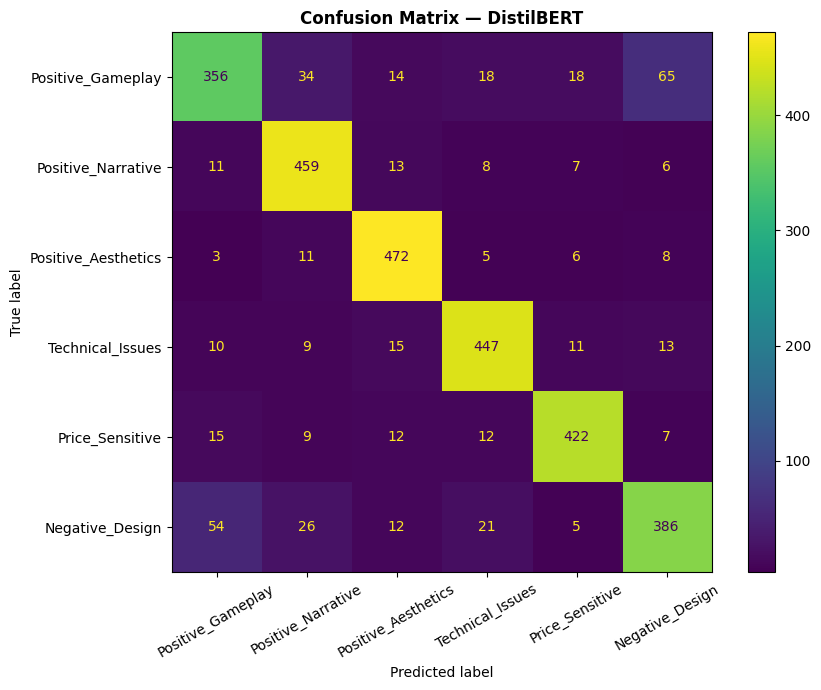


  BERTweet
                     precision    recall  f1-score   support

  Positive_Gameplay       0.79      0.82      0.80       505
 Positive_Narrative       0.89      0.90      0.90       504
Positive_Aesthetics       0.89      0.95      0.92       505
   Technical_Issues       0.89      0.91      0.90       505
    Price_Sensitive       0.93      0.88      0.90       477
    Negative_Design       0.88      0.80      0.83       504

           accuracy                           0.88      3000
          macro avg       0.88      0.88      0.88      3000
       weighted avg       0.88      0.88      0.88      3000



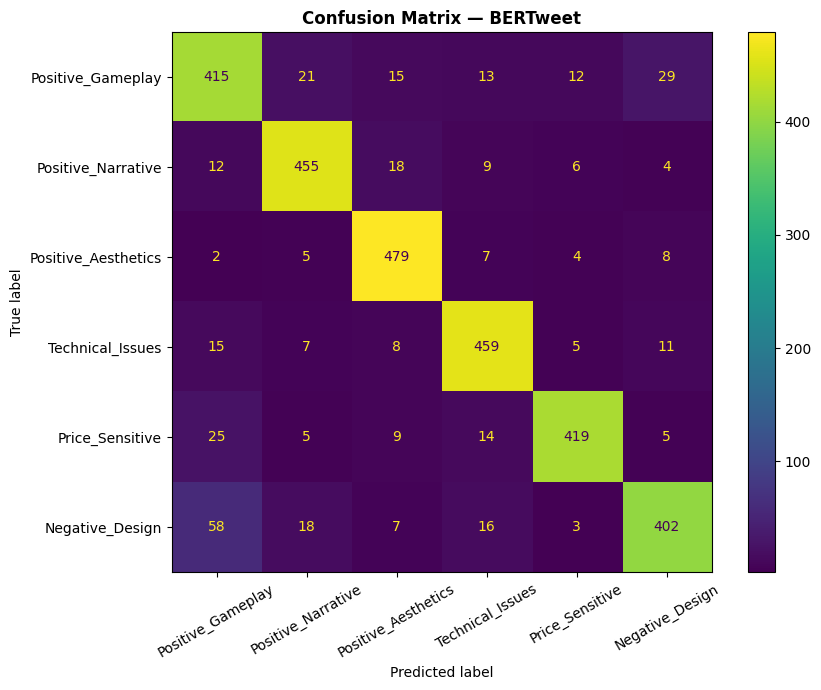


  RoBERTa
                     precision    recall  f1-score   support

  Positive_Gameplay       0.81      0.78      0.80       505
 Positive_Narrative       0.90      0.88      0.89       504
Positive_Aesthetics       0.88      0.95      0.91       505
   Technical_Issues       0.92      0.93      0.92       505
    Price_Sensitive       0.93      0.94      0.93       477
    Negative_Design       0.85      0.83      0.84       504

           accuracy                           0.88      3000
          macro avg       0.88      0.88      0.88      3000
       weighted avg       0.88      0.88      0.88      3000



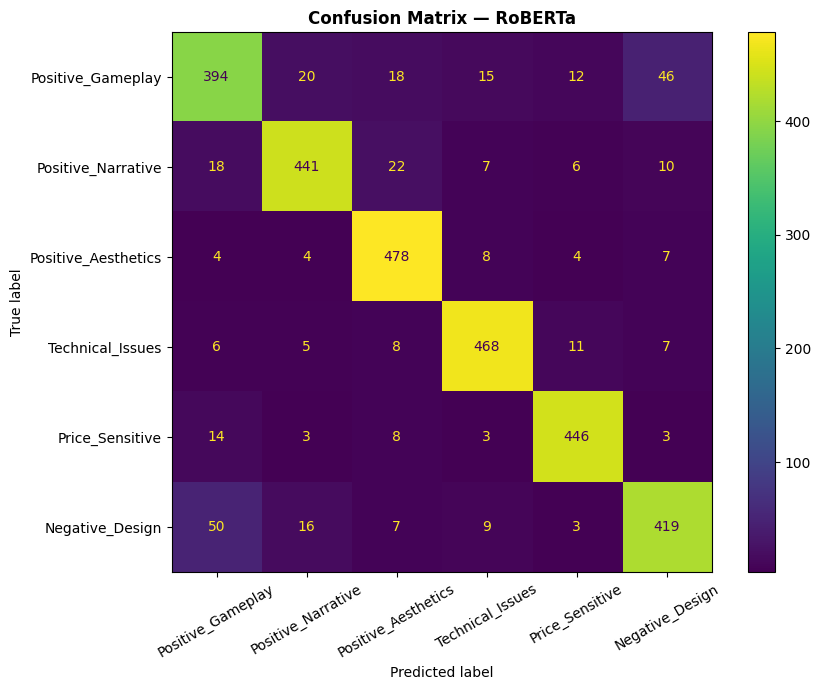

In [ ]:
target_names = list(label_names.values())

def evaluate_model(trainer, test_dataset, model_name):
    preds = trainer.predict(test_dataset)
    y_pred = np.argmax(preds.predictions, axis=1)
    y_true = preds.label_ids

    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(classification_report(y_true, y_pred, target_names=target_names))

    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=target_names).plot(ax=ax, xticks_rotation=30)
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return classification_report(y_true, y_pred, target_names=target_names, output_dict=True)

r1 = evaluate_model(trainer, test_tok, "DistilBERT")
r2 = evaluate_model(trainer2, test_tok2, "BERTweet")
r3 = evaluate_model(trainer3, test_tok3, "RoBERTa")

                     DistilBERT  BERTweet  RoBERTa
Positive_Gameplay        0.7463    0.8043   0.7952
Positive_Narrative       0.8726    0.8966   0.8882
Positive_Aesthetics      0.9051    0.9203   0.9140
Technical_Issues         0.8799    0.8974   0.9222
Price_Sensitive          0.8922    0.9050   0.9301
Negative_Design          0.7806    0.8349   0.8414


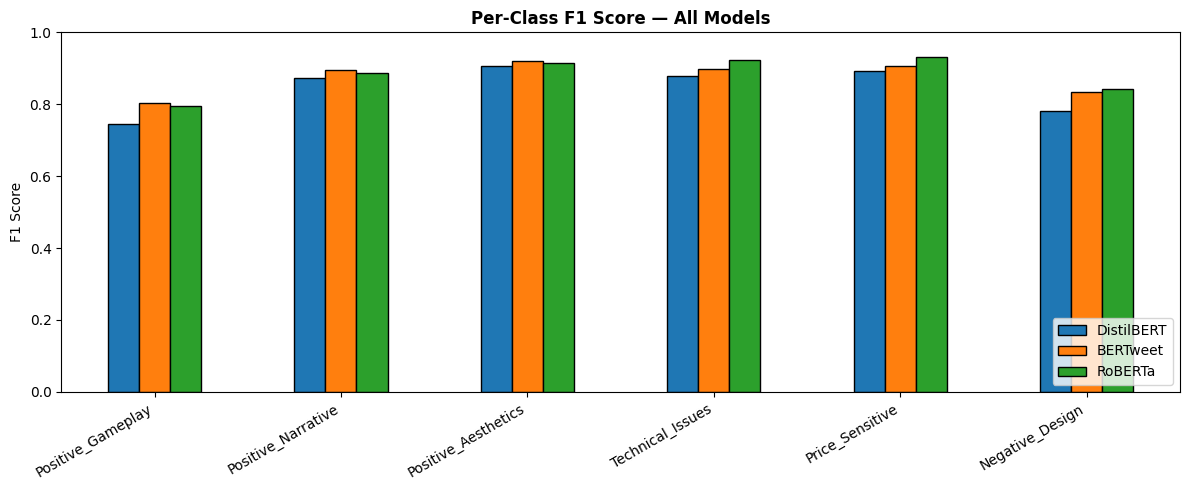

In [ ]:
# Per-class F1 comparison
classes = list(label_names.values())
per_class_f1 = pd.DataFrame({
    'DistilBERT': [r1[c]['f1-score'] for c in classes],
    'BERTweet':   [r2[c]['f1-score'] for c in classes],
    'RoBERTa':    [r3[c]['f1-score'] for c in classes],
}, index=classes).round(4)

print(per_class_f1)
per_class_f1.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Per-Class F1 Score — All Models', fontweight='bold')
plt.ylabel('F1 Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

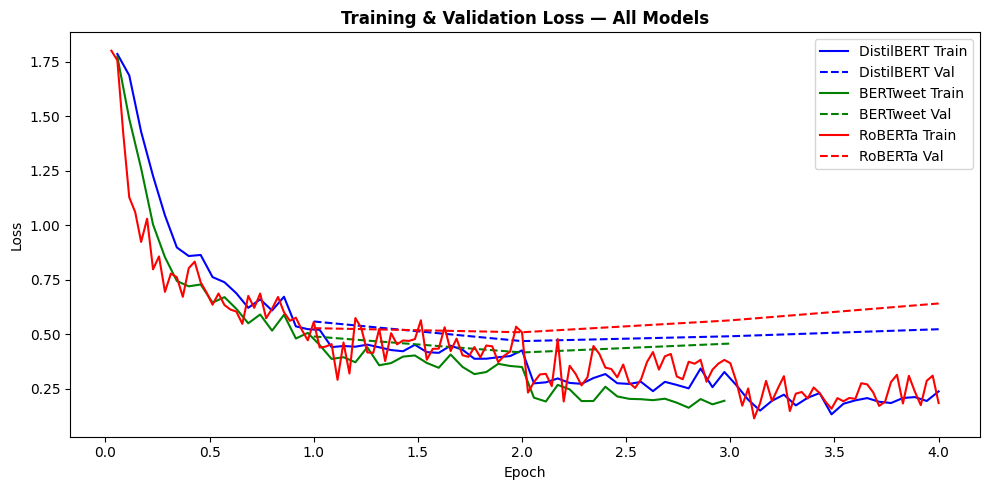

In [ ]:
# Training loss curves
def plot_loss(trainer_obj, model_name, color):
    logs = trainer_obj.state.log_history
    train_logs = [(x['epoch'], x['loss'])      for x in logs if 'loss' in x and 'eval_loss' not in x]
    eval_logs  = [(x['epoch'], x['eval_loss']) for x in logs if 'eval_loss' in x]
    if train_logs:
        e, l = zip(*train_logs)
        plt.plot(e, l, label=f'{model_name} Train', color=color, linestyle='-')
    if eval_logs:
        e, l = zip(*eval_logs)
        plt.plot(e, l, label=f'{model_name} Val', color=color, linestyle='--')

plt.figure(figsize=(10, 5))
plot_loss(trainer,  "DistilBERT", "blue")
plot_loss(trainer2, "BERTweet",   "green")
plot_loss(trainer3, "RoBERTa",    "red")
plt.title('Training & Validation Loss — All Models', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('images/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

           DistilBERT  BERTweet  RoBERTa
precision      0.8459    0.8773   0.8814
recall         0.8473    0.8763   0.8820
f1-score       0.8457    0.8761   0.8814


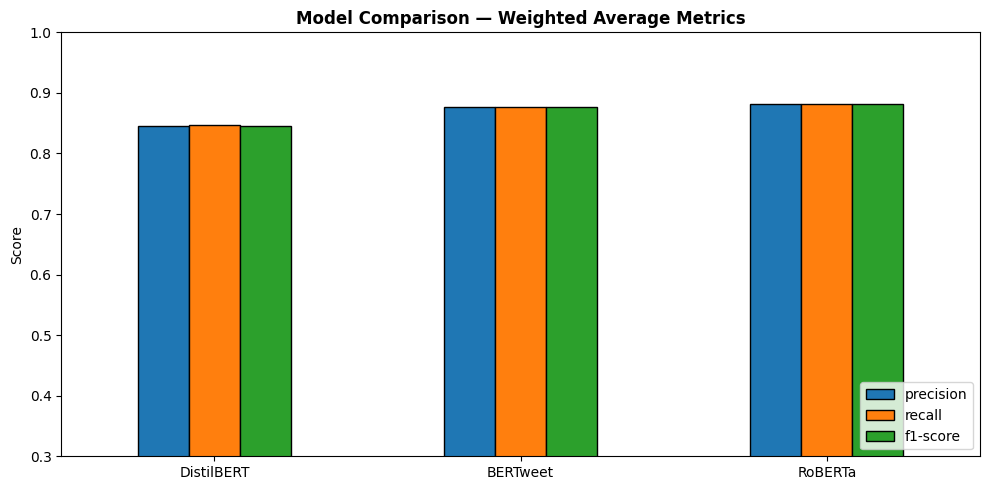

In [ ]:
# Final comparison table
metrics = ['precision', 'recall', 'f1-score']
comparison = pd.DataFrame({
    'DistilBERT': [r1['weighted avg'][m] for m in metrics],
    'BERTweet':   [r2['weighted avg'][m] for m in metrics],
    'RoBERTa':    [r3['weighted avg'][m] for m in metrics],
}, index=metrics).round(4)

print(comparison)

comparison.T.plot(kind='bar', figsize=(10,5), edgecolor='black')
plt.title('Model Comparison — Weighted Average Metrics', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.3, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Weakest class per model
print("=== Weakest Class Per Model ===\n")
for name, results in [("DistilBERT", r1), ("BERTweet", r2), ("RoBERTa", r3)]:
    class_f1s = {c: results[c]['f1-score'] for c in classes}
    worst = min(class_f1s, key=class_f1s.get)
    best  = max(class_f1s, key=class_f1s.get)
    print(f"{name}:")
    print(f"  Best  → {best:<25} F1: {class_f1s[best]:.4f}")
    print(f"  Worst → {worst:<25} F1: {class_f1s[worst]:.4f}\n")

=== Weakest Class Per Model ===

DistilBERT:
  Best  → Positive_Aesthetics       F1: 0.9051
  Worst → Positive_Gameplay         F1: 0.7463

BERTweet:
  Best  → Positive_Aesthetics       F1: 0.9203
  Worst → Positive_Gameplay         F1: 0.8043

RoBERTa:
  Best  → Price_Sensitive           F1: 0.9301
  Worst → Positive_Gameplay         F1: 0.7952

